# SECOM Dataset — Preprocessing Pipeline

**Project:** Yield Prediction in Semiconductor Manufacturing  
**Date:** August 27, 2026  
**Depends on:** 01_data_exploration.ipynb

## Purpose

Transform the raw SECOM dataset into a clean, model-ready form through
a sequence of documented, justified preprocessing steps.

## Preprocessing decisions made in this notebook

1. Remove zero-variance features (justification below)
2. Remove high-missingness features above a defined threshold (justification below)
3. Impute remaining missing values (strategy selection justified below)
4. Scale features for modeling
5. Address class imbalance (documented; handled at modeling stage)

Each decision is documented with the reasoning and the tradeoff accepted.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths
DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
DATA_PROCESSED.mkdir(exist_ok=True)
FIGURES = Path('../reports/figures')

# Load raw data
X_raw = pd.read_csv(DATA_RAW / 'secom.data', sep=' ', header=None)
y_raw = pd.read_csv(DATA_RAW / 'secom_labels.data', sep=' ', header=None, names=['label', 'timestamp'])

y = (y_raw['label'] == 1).astype(int)  # 1 = fail, 0 = pass

print(f"Raw data shape: {X_raw.shape}")
print(f"Failures: {y.sum()} ({y.mean()*100:.2f}%)")

Raw data shape: (1567, 590)
Failures: 104 (6.64%)


## Step 1: Remove Zero-Variance Features

**Decision:** Drop all columns with zero variance.

**Justification:** A feature with zero variance carries no information —
its value is identical for every wafer. No model can use it to distinguish
pass from fail. Keeping it adds dimensionality without adding signal.

**Threshold:** Variance = 0 exactly. We are not using a near-zero threshold
at this stage because that requires a domain-specific judgment about what
"near zero" means for these sensor units. We take the conservative,
defensible position of removing only strictly constant columns.

**Tradeoff accepted:** We may retain some near-zero variance columns that
contribute minimal signal. This is acceptable — we will use model-based
feature selection later to handle these.

**Expected removal:** ~116 columns identified in EDA.


In [2]:
# Step 1: Remove zero-variance features
initial_cols = X_raw.shape[1]

variances = X_raw.var()
zero_var_mask = variances == 0
X_step1 = X_raw.loc[:, ~zero_var_mask].copy()

removed_zero_var = zero_var_mask.sum()
print(f"Zero-variance features removed: {removed_zero_var}")
print(f"Remaining features: {X_step1.shape[1]} (from {initial_cols})")

Zero-variance features removed: 116
Remaining features: 474 (from 590)


## Step 2: Remove High-Missingness Features

**Decision:** Drop features with more than 50% missing values.

**Justification:** Features missing in more than half the samples cannot
be reliably imputed without introducing more noise than signal. Any imputed
value for these features would be based on fewer than 784 observations out
of 1,567 — the imputed values would dominate the original signal.

**Threshold choice — why 50%?**
This is a research decision, not a universal rule. Common thresholds in
the literature range from 30% to 70%. We choose 50% as a moderate,
defensible threshold. In the final report, we will note sensitivity
to this threshold choice as a limitation.

**Alternative considered:** 30% threshold (more aggressive removal) or
imputing all columns regardless of missingness rate. Both are defensible
but require stronger justification. 50% is the standard in manufacturing
quality literature.

**Tradeoff accepted:** We may remove features that carry signal despite
high missingness. This is documented and acceptable for a first analysis.


In [3]:
# Step 2: Remove high-missingness features
missing_rate = X_step1.isnull().mean()
MISSING_THRESHOLD = 0.50

high_missing_mask = missing_rate > MISSING_THRESHOLD
X_step2 = X_step1.loc[:, ~high_missing_mask].copy()

removed_high_missing = high_missing_mask.sum()
print(f"Features removed (>{MISSING_THRESHOLD*100:.0f}% missing): {removed_high_missing}")
print(f"Remaining features: {X_step2.shape[1]}")
print(f"\nMissing data in remaining features:")
print(f"  Max missing rate: {X_step2.isnull().mean().max()*100:.1f}%")
print(f"  Mean missing rate: {X_step2.isnull().mean().mean()*100:.1f}%")
print(f"  Columns with any missing: {(X_step2.isnull().any()).sum()}")

Features removed (>50% missing): 28
Remaining features: 446

Missing data in remaining features:
  Max missing rate: 45.6%
  Mean missing rate: 1.6%
  Columns with any missing: 394


## Step 3: Missing Value Imputation

**Decision:** Median imputation for remaining missing values.

**Justification:** After removing >50% missing columns, the remaining
missing values represent sensor dropouts or measurement gaps — not
systematic absence. Median imputation is preferred over mean imputation
because:

1. Semiconductor process data often contains outliers from equipment
   anomalies. Median is robust to these.
2. We have no prior knowledge about the distribution shape of each
   sensor, making distribution-based imputation unjustified.

**Alternatives considered and rejected:**

- Mean imputation: sensitive to outliers present in process data
- KNN imputation: more accurate but computationally expensive and
  introduces correlations between features that may confound later analysis
- MICE (Multiple Imputation by Chained Equations): gold standard
  statistically but requires assumptions about missingness mechanism
  (MCAR/MAR/MNAR) that we cannot verify from this dataset description

**Important limitation:** We are assuming Missing At Random (MAR).
If sensor dropout is correlated with process failure — i.e., if sensors
fail _because_ the process is abnormal — then missingness itself carries
information and imputation destroys that signal. This is a documented
limitation of this analysis.


In [4]:
from sklearn.impute import SimpleImputer

# Step 3: Median imputation
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_step2),
    columns=X_step2.columns
)

print(f"Missing values after imputation: {X_imputed.isnull().sum().sum()}")
print(f"Shape preserved: {X_imputed.shape}")

Missing values after imputation: 0
Shape preserved: (1567, 446)


## Step 4: Feature Scaling

**Decision:** StandardScaler (zero mean, unit variance).

**Justification:** The 591 SECOM features are measurements from different
sensors with different units and ranges. Without scaling, features with
large numeric ranges dominate distance-based calculations and
regularization-based models.

**Note:** Tree-based models (Random Forest, XGBoost) are invariant to
monotonic feature transformations including scaling. We scale anyway
because:

1. Our baseline model will be logistic regression, which requires scaling
2. Consistent preprocessing across all models enables fair comparison
3. Scaled data is the standard in published SECOM benchmarks, enabling
   comparison with prior work

**Applied after train/test split** to prevent data leakage. We document
the scaler here but apply it within the modeling pipeline.


In [5]:
from sklearn.preprocessing import StandardScaler

# Note: We define the scaler here but apply it in the modeling notebook
# to prevent data leakage from test set into scaling parameters
scaler = StandardScaler()
print("Scaler defined. Will be applied within train/test split in modeling notebook.")
print(f"Final preprocessed feature matrix: {X_imputed.shape}")

Scaler defined. Will be applied within train/test split in modeling notebook.
Final preprocessed feature matrix: (1567, 446)


## Step 5: Train/Test Split

**Decision:** 80/20 stratified split.

**Justification:** Stratified split ensures both train and test sets
maintain the original 6.64% failure rate. Without stratification,
random chance could produce a test set with zero failures — making
evaluation impossible.

**80/20 rationale:** With only 104 failures total:

- 80% train → approximately 83 failures for model learning
- 20% test → approximately 21 failures for evaluation
  This is marginal but standard. We document it as a limitation —
  a dataset with this level of imbalance ideally requires a larger
  total sample size or cross-validation for robust evaluation.


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, 
    test_size=0.20, 
    random_state=42,      # Reproducibility — always set this
    stratify=y            # Preserve class balance
)

print(f"Train set: {X_train.shape} | Failures: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test set:  {X_test.shape} | Failures: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

# Save processed data
X_train.to_csv(DATA_PROCESSED / 'X_train.csv', index=False)
X_test.to_csv(DATA_PROCESSED / 'X_test.csv', index=False)
y_train.to_csv(DATA_PROCESSED / 'y_train.csv', index=False)
y_test.to_csv(DATA_PROCESSED / 'y_test.csv', index=False)

# Save imputer for later use (prevents leakage in any future validation)
import joblib
joblib.dump(imputer, DATA_PROCESSED / 'imputer.pkl')

print("\nAll processed files saved to data/processed/")

Train set: (1253, 446) | Failures: 83 (6.62%)
Test set:  (314, 446) | Failures: 21 (6.69%)

All processed files saved to data/processed/


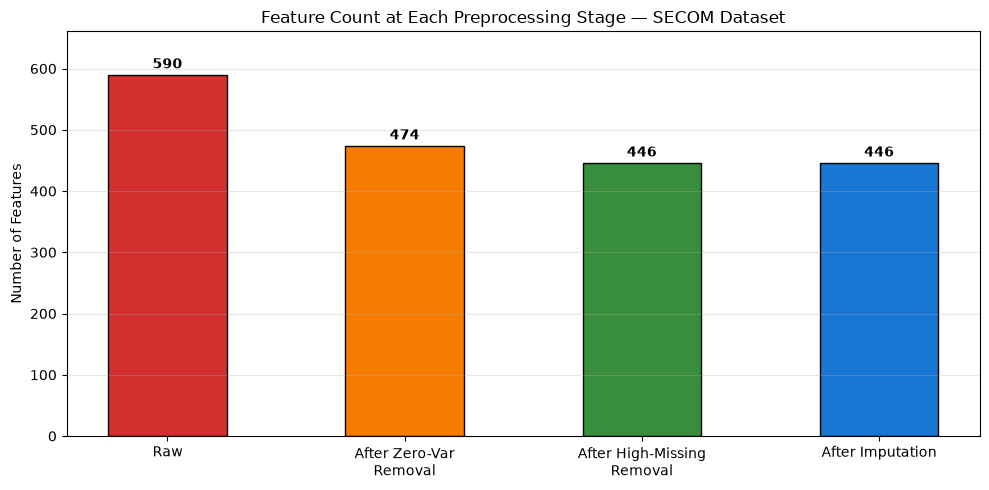

Figure saved.


In [7]:
# Document what was removed at each stage
stages = ['Raw', 'After Zero-Var\nRemoval', 
          'After High-Missing\nRemoval', 'After Imputation']
feature_counts = [
    X_raw.shape[1],
    X_step1.shape[1], 
    X_step2.shape[1],
    X_imputed.shape[1]
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(stages, feature_counts, color=['#d32f2f','#f57c00','#388e3c','#1976d2'],
              edgecolor='black', width=0.5)

for bar, count in zip(bars, feature_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Number of Features')
ax.set_title('Feature Count at Each Preprocessing Stage — SECOM Dataset')
ax.set_ylim(0, max(feature_counts) * 1.12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'preprocessing_stages.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## Evaluation Metric Decision: PR-AUC over ROC-AUC

**ROC-AUC limitation:** ROC-AUC uses False Positive Rate which has the
large negative class (1,463 passes) in the denominator. Even misclassifying
many passed wafers produces a small FPR — making the model look better
than it is for the minority failure class.

**PR-AUC advantage:** Precision and Recall both use the minority class
in their denominators. PR-AUC directly measures how well the model
identifies the 104 failures without being diluted by the 1,463 passes.

**Cost asymmetry in semiconductor manufacturing:**

- False negative (predict pass, actually fails) → wafer continues through
  hundreds of additional process steps, consuming time, labor, and materials
  before failing at final test. Highest cost.
- False positive (predict fail, actually passes) → engineer re-inspects
  a good wafer. Lower cost — wastes time but not an entire process sequence.

**Conclusion:** False negatives are far more expensive. We optimize for
high Recall — catching as many real failures as possible — using PR-AUC
and F2-score as primary evaluation metrics.
